<a href="https://colab.research.google.com/github/i-ganza007/Match_Backend/blob/main/DraftBreedRecogntion_PureCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

data_path = '/content/drive/MyDrive/Data'
print(f'Drive mounted. Data path set to: {data_path}')

Mounted at /content/drive
Drive mounted. Data path set to: /content/drive/MyDrive/Data


In [2]:
all_items = os.listdir(data_path)

# Filter to include only directories (representing classes) and exclude hidden files
classes = [item for item in all_items if os.path.isdir(os.path.join(data_path, item)) and not item.startswith('.')]

# Sort classes for consistent label mapping (important for class weights)
classes = sorted(classes)

print(f'Found {len(classes)} classes (sorted): {classes}')

# Check for any unexpected files in the root directory
non_dir_items = [item for item in all_items if not os.path.isdir(os.path.join(data_path, item))]
if non_dir_items:
    print(f'Warning: Found non-directory items in data path: {non_dir_items}')

Found 14 classes (sorted): ['brown_swiss_cow', 'dorper_sheep', 'duroc_pig', 'fresian_cow', 'girolando_cow', 'indigenous_ankole_cow', 'indigenous_goat', 'indigenous_pig', 'jersey_cow', 'landrace_pig', 'large_white_pig', 'merino_sheep', 'pietrain_pig', 'sahiwal_cow']


In [3]:
label_to_int = {label: idx for idx, label in enumerate(classes)}

data = []
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

for label in classes:
    class_path = os.path.join(data_path, label)
    for filename in os.listdir(class_path):
        if filename.lower().endswith(valid_extensions):
            filepath = os.path.join(class_path, filename)
            data.append({'filepath': filepath, 'label': label})

# Create a DataFrame
df = pd.DataFrame(data)
print(f'Total images found: {len(df)}')
print(df.head())

# Check class distribution
print('\nClass distribution:')
print(df['label'].value_counts())

Total images found: 689
                                            filepath            label
0  /content/drive/MyDrive/Data/brown_swiss_cow/0_...  brown_swiss_cow
1  /content/drive/MyDrive/Data/brown_swiss_cow/1_...  brown_swiss_cow
2  /content/drive/MyDrive/Data/brown_swiss_cow/2_...  brown_swiss_cow
3  /content/drive/MyDrive/Data/brown_swiss_cow/3_...  brown_swiss_cow
4  /content/drive/MyDrive/Data/brown_swiss_cow/4_...  brown_swiss_cow

Class distribution:
label
girolando_cow            67
indigenous_ankole_cow    58
fresian_cow              57
dorper_sheep             56
landrace_pig             56
brown_swiss_cow          54
merino_sheep             49
large_white_pig          48
jersey_cow               46
pietrain_pig             43
sahiwal_cow              42
indigenous_goat          42
duroc_pig                38
indigenous_pig           33
Name: count, dtype: int64


In [4]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['label'])

print(f'Training samples: {len(train_df)}')
print(f'Validation samples: {len(val_df)}')
print(f'Testing samples: {len(test_df)}')

# Verify stratification
print('\nValidation set class distribution:')
print(val_df['label'].value_counts())

Training samples: 482
Validation samples: 103
Testing samples: 104

Validation set class distribution:
label
girolando_cow            10
dorper_sheep              8
landrace_pig              8
brown_swiss_cow           8
fresian_cow               8
indigenous_ankole_cow     8
jersey_cow                7
sahiwal_cow               7
large_white_pig           7
indigenous_goat           7
merino_sheep              7
pietrain_pig              7
duroc_pig                 6
indigenous_pig            5
Name: count, dtype: int64


In [5]:
print('\nComputing class weights...')
y_train_int = train_df['label'].map(label_to_int).values
unique_int = np.unique(y_train_int)
weights = compute_class_weight('balanced', classes=unique_int, y=y_train_int)
class_weight_dict = dict(zip(unique_int, weights))

# 10x boost for rare breeds
rare_breeds = ['Sahiwal', 'Pietrain']   # add more if needed
for breed in rare_breeds:
    if breed in label_to_int:
        idx = label_to_int[breed]
        if idx in class_weight_dict:
            class_weight_dict[idx] *= 10.0
            print(f'Applied 10x weight multiplier to rare breed: {breed} (index {idx})')

print('Class weight dictionary:', class_weight_dict)

# Label-smoothed loss
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)
num_classes = len(classes)

# ====================== RAW CNN MODEL ======================
model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 4
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Classifier head
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()


Computing class weights...
Class weight dictionary: {np.int64(0): np.float64(0.9060150375939849), np.int64(1): np.float64(0.8827838827838828), np.int64(2): np.float64(1.2751322751322751), np.int64(3): np.float64(0.8607142857142858), np.int64(4): np.float64(0.7325227963525835), np.int64(5): np.float64(0.8397212543554007), np.int64(6): np.float64(1.187192118226601), np.int64(7): np.float64(1.4968944099378882), np.int64(8): np.float64(1.0758928571428572), np.int64(9): np.float64(0.8827838827838828), np.int64(10): np.float64(1.0126050420168067), np.int64(11): np.float64(1.0126050420168067), np.int64(12): np.float64(1.1476190476190475), np.int64(13): np.float64(1.187192118226601)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,875,950 (102.52 MB)

 Trainable params: 26,873,006 (102.51 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [6]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    channel_shift_range=20.0,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator()   # no augmentation for val/test

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    classes=classes
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

Found 482 validated image filenames belonging to 14 classes.
Found 103 validated image filenames belonging to 14 classes.
Found 104 validated image filenames belonging to 14 classes.


In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

# Phase 1: Higher learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

print('\n=== Starting Phase 1: Training raw CNN from scratch ===')
history_phase1 = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

# Phase 2: Lower learning rate refinement
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)


=== Starting Phase 1: Training raw CNN from scratch ===
Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 244s 13s/step - accuracy: 0.1203 - loss: 3.4461 - val_accuracy: 0.1262 - val_loss: 15.7351 - learning_rate: 0.0010
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1162 - loss: 3.0950 - val_accuracy: 0.0874 - val_loss: 9.8040 - learning_rate: 0.0010
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1141 - loss: 3.0348 - val_accuracy: 0.0971 - val_loss: 7.5851 - learning_rate: 0.0010
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1411 - loss: 2.9186 - val_accuracy: 0.1165 - val_loss: 5.9862 - learning_rate: 0.0010
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2012 - loss: 2.8167 - val_accuracy: 0.1262 - val_loss: 3.5328 - learning_rate: 0.0010
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1763 - loss: 2.9994 - val_accuracy: 0.0291 - val_loss: 3.5225 - learning_rate: 0.0010
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 20

In [8]:
print('\n=== Starting Phase 2: Lower LR refinement ===')
history_phase2 = model.fit(
    train_generator,
    epochs=60,           # total epochs can go up to ~100 if needed
    initial_epoch=len(history_phase1.history['loss']),
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

print('\nRaw CNN training completed.')


=== Starting Phase 2: Lower LR refinement ===
Epoch 15/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.1535 - loss: 3.0437 - val_accuracy: 0.0874 - val_loss: 3.1536 - learning_rate: 1.0000e-04
Epoch 16/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1639 - loss: 2.9058 - val_accuracy: 0.1262 - val_loss: 2.8896 - learning_rate: 1.0000e-04
Epoch 17/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2178 - loss: 2.7834 - val_accuracy: 0.1456 - val_loss: 2.7374 - learning_rate: 1.0000e-04
Epoch 18/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.2095 - loss: 2.6931 - val_accuracy: 0.1650 - val_loss: 2.6741 - learning_rate: 1.0000e-04
Epoch 19/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2510 - loss: 2.7090 - val_accuracy: 0.1942 - val_loss: 2.5751 - learning_rate: 1.0000e-04
Epoch 20/60
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2407 - loss: 2.7180 - val_accuracy: 0.1845 - val_loss: 2.6177 - learning_rate: 1.0000e-04
Epoch 21/60
16/16 ━━━━━


Evaluating the final model on the test set (single pass)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 555ms/step - accuracy: 0.1923 - loss: 2.5848
Test Accuracy (single): 0.1923
Test Loss (single): 2.5848


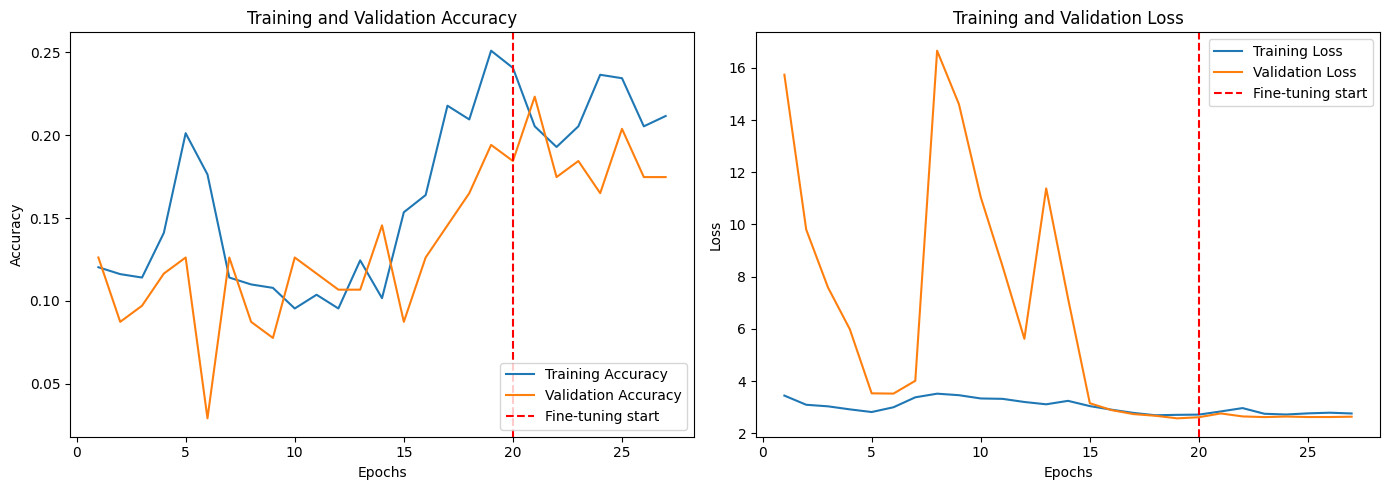

In [10]:
print('\nEvaluating the final model on the test set (single pass)...')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Accuracy (single): {test_acc:.4f}')
print(f'Test Loss (single): {test_loss:.4f}')

# Plot combined history
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=20, color='r', linestyle='--', label='Fine-tuning start')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=20, color='r', linestyle='--', label='Fine-tuning start')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Generating predictions for the test dataset (single pass)...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 556ms/step

Classification Report (single pass):
                       precision    recall  f1-score   support

      brown_swiss_cow       0.12      0.50      0.20         8
         dorper_sheep       0.44      0.44      0.44         9
            duroc_pig       0.09      0.20      0.12         5
          fresian_cow       1.00      0.11      0.20         9
        girolando_cow       1.00      0.20      0.33        10
indigenous_ankole_cow       0.50      0.11      0.18         9
      indigenous_goat       0.00      0.00      0.00         6
       indigenous_pig       0.50      0.40      0.44         5
           jersey_cow       0.00      0.00      0.00         7
         landrace_pig       0.12      0.33      0.18         9
      large_white_pig       0.00      0.00      0.00         7
         merino_sheep       0.33      0.12      0.18         8
         pietrain_pig       0.11      0.17

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


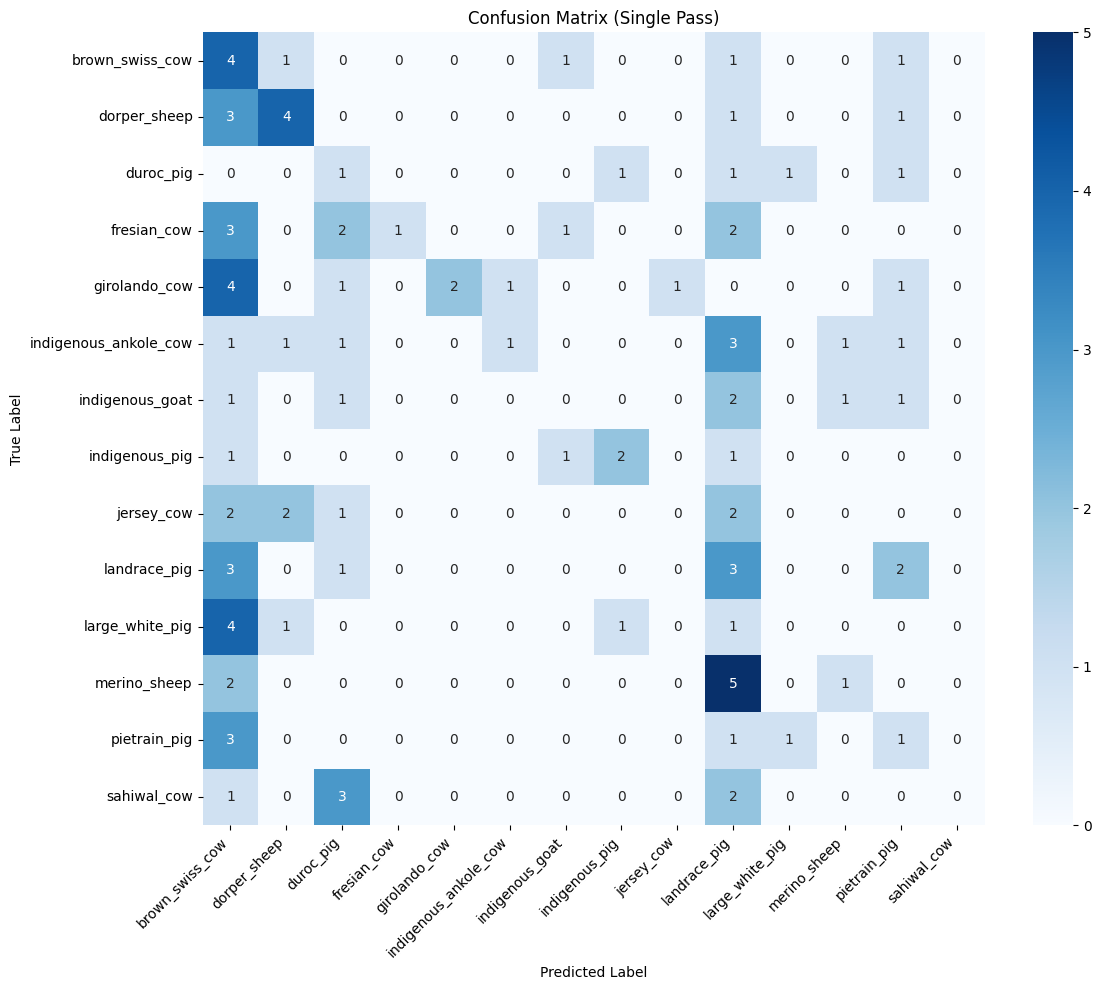


Performing Test-Time Augmentation (TTA) with 5 augmented versions...
Found 104 validated image filenames belonging to 14 classes.
TTA pass 1/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 997ms/step
TTA pass 2/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 863ms/step
TTA pass 3/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
TTA pass 4/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 873ms/step
TTA pass 5/5...
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step

Classification Report (TTA):
                       precision    recall  f1-score   support

      brown_swiss_cow       0.00      0.00      0.00         8
         dorper_sheep       0.00      0.00      0.00         9
            duroc_pig       0.00      0.00      0.00         5
          fresian_cow       0.00      0.00      0.00         9
        girolando_cow       0.00      0.00      0.00        10
indigenous_ankole_cow       0.00      0.00      0.00         9
      indigenous_goat       0.00      0.00      0.00         6
       indigenous_pig       0.05      1.00      0.09         5
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


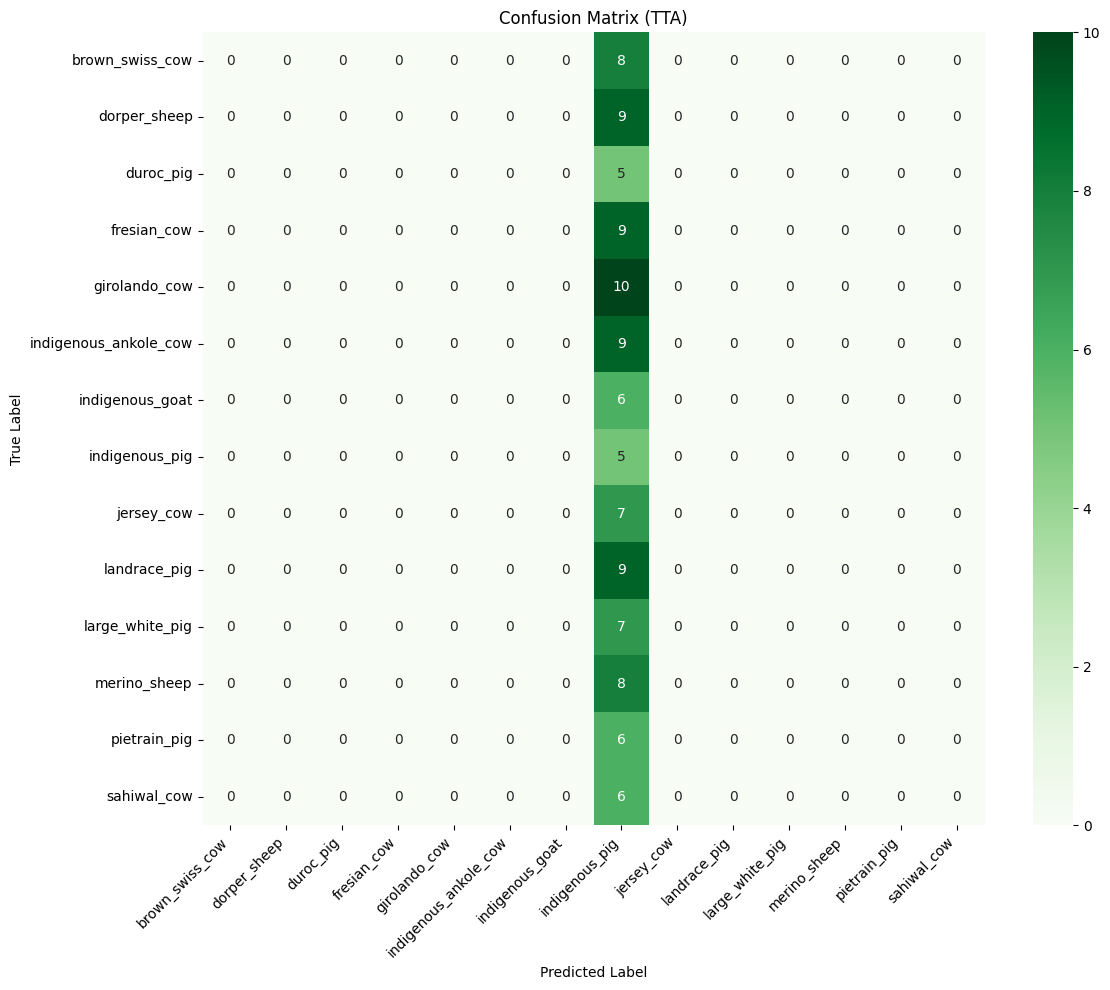

In [11]:
print('Generating predictions for the test dataset (single pass)...')
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print('\nClassification Report (single pass):')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix (original)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Single Pass)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Test-Time Augmentation (TTA) for better generalization on rare classes
print('\nPerforming Test-Time Augmentation (TTA) with 5 augmented versions...')
tta_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.9, 1.1],
    shear_range=5.0,
    channel_shift_range=10.0,
    fill_mode='nearest'
)

tta_generator = tta_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False,
    classes=classes
)

n_tta = 5
tta_preds = []
for i in range(n_tta):
    print(f'TTA pass {i+1}/{n_tta}...')
    tta_generator.reset()
    pred = model.predict(tta_generator, verbose=1)
    tta_preds.append(pred)

avg_tta_probs = np.mean(tta_preds, axis=0)
y_pred_tta = np.argmax(avg_tta_probs, axis=1)

print('\nClassification Report (TTA):')
print(classification_report(y_true, y_pred_tta, target_names=class_names))

cm_tta = confusion_matrix(y_true, y_pred_tta)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (TTA)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()